# Simple GAN Pipeline on Fashion-MNIST (TensorFlow, Colab)

Full DCGAN pipeline: data → generator → discriminator → training loop → visualization.

**Before running:** In Colab, go to `Runtime > Change runtime type > Hardware accelerator > GPU` for a big speedup.

In [1]:
import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import os
import time
import numpy as np
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from IPython import display  # for live inline plotting in Colab

## 0. Config

In [3]:
BUFFER_SIZE = 60000
BATCH_SIZE = 256
NOISE_DIM = 100          # size of the random noise vector fed to the generator
EPOCHS = 500               # increase for better quality
NUM_EXAMPLES_TO_GENERATE = 16
OUTPUT_DIR = "gan_fashion_output"
CHECKPOINT_DIR = os.path.join(OUTPUT_DIR, "checkpoints")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

FASHION_CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

## 1. Data loading & preprocessing

In [4]:
def load_data():
    (train_images, _), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

    # Reshape to (N, 28, 28, 1) and cast to float32
    train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype("float32")

    # Normalize images to [-1, 1] because the generator's final activation is tanh
    train_images = (train_images - 127.5) / 127.5

    dataset = tf.data.Dataset.from_tensor_slices(train_images)
    dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE)
    return dataset

train_dataset = load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


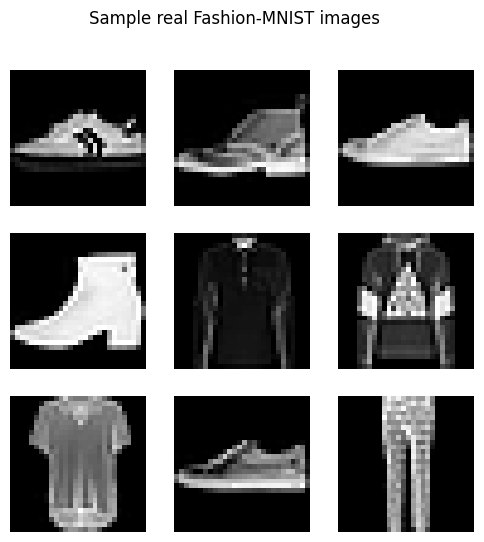

In [5]:
# Quick sanity check: preview a few real training images
for batch in train_dataset.take(1):
    plt.figure(figsize=(6, 6))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(batch[i, :, :, 0] * 0.5 + 0.5, cmap="gray")
        plt.axis("off")
    plt.suptitle("Sample real Fashion-MNIST images")
    plt.show()

## 2. Generator: noise vector -> 28x28x1 fake image

In [6]:
def make_generator_model():
    model = tf.keras.Sequential(name="generator")

    # Project noise into a small spatial feature map, then upsample
    model.add(layers.Dense(7 * 7 * 256, use_bias=False, input_shape=(NOISE_DIM,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))
    assert model.output_shape == (None, 7, 7, 256)

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    assert model.output_shape == (None, 7, 7, 128)

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    assert model.output_shape == (None, 14, 14, 64)

    # Final layer: tanh output in range [-1, 1] to match preprocessed data
    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding="same",
                                      use_bias=False, activation="tanh"))
    assert model.output_shape == (None, 28, 28, 1)

    return model

generator = make_generator_model()
generator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

## 3. Discriminator: 28x28x1 image -> single real/fake logit

In [7]:
def make_discriminator_model():
    model = tf.keras.Sequential(name="discriminator")

    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding="same",
                             input_shape=[28, 28, 1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding="same"))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))  # raw logit, no activation (used with from_logits=True loss)

    return model

discriminator = make_discriminator_model()
discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Losses & optimizers

In [8]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)


def discriminator_loss(real_output, fake_output):
    # Real images should be classified as 1, fake images as 0
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss


def generator_loss(fake_output):
    # Generator wants the discriminator to classify fakes as real (1)
    return cross_entropy(tf.ones_like(fake_output), fake_output)


generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

## 5. Checkpointing (saves to Colab's local disk; mount Drive if you want it to persist)

In [9]:
checkpoint_prefix = os.path.join(CHECKPOINT_DIR, "ckpt")
checkpoint = tf.train.Checkpoint(
    generator_optimizer=generator_optimizer,
    discriminator_optimizer=discriminator_optimizer,
    generator=generator,
    discriminator=discriminator,
)

## 6. Training step

In [10]:
@tf.function
def train_step(images):
    noise = tf.random.normal([images.shape[0], NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

## 7. Visualization helpers (inline display, ideal for Colab)

In [11]:
def generate_and_show_images(model, epoch, test_input):
    predictions = model(test_input, training=False)

    display.clear_output(wait=True)
    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap="gray")
        plt.axis("off")
    plt.suptitle(f"Epoch {epoch}")
    fig.savefig(os.path.join(OUTPUT_DIR, f"epoch_{epoch:03d}.png"))
    plt.show()


def plot_losses(gen_losses, disc_losses):
    plt.figure(figsize=(8, 5))
    plt.plot(gen_losses, label="Generator loss")
    plt.plot(disc_losses, label="Discriminator loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("GAN Training Losses")
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, "loss_curve.png"))
    plt.show()

## 8. Full training loop

This will re-display the generated grid after every epoch (via `display.clear_output`), so you get a live animation-style view of the generator improving as training runs.

In [12]:
def train(dataset, epochs):
    seed = tf.random.normal([NUM_EXAMPLES_TO_GENERATE, NOISE_DIM])  # fixed seed to watch progress

    gen_loss_history, disc_loss_history = [], []

    for epoch in range(epochs):
        start = time.time()
        epoch_gen_losses, epoch_disc_losses = [], []

        for image_batch in dataset:
            g_loss, d_loss = train_step(image_batch)
            epoch_gen_losses.append(float(g_loss))
            epoch_disc_losses.append(float(d_loss))

        gen_loss_history.append(np.mean(epoch_gen_losses))
        disc_loss_history.append(np.mean(epoch_disc_losses))

        generate_and_show_images(generator, epoch + 1, seed)

        if (epoch + 1) % 10 == 0:
            checkpoint.save(file_prefix=checkpoint_prefix)

        print(f"Epoch {epoch + 1}/{epochs} | "
              f"gen_loss={gen_loss_history[-1]:.4f} disc_loss={disc_loss_history[-1]:.4f} "
              f"| time={time.time() - start:.1f}s")

    plot_losses(gen_loss_history, disc_loss_history)
    return gen_loss_history, disc_loss_history

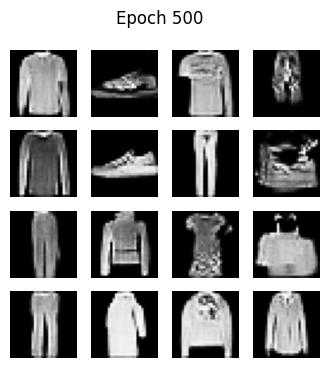

Epoch 500/500 | gen_loss=0.8775 disc_loss=1.2918 | time=14.5s


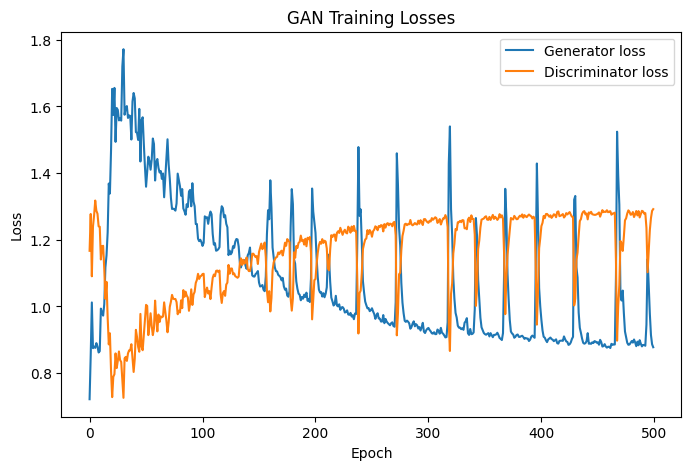

In [13]:
gen_losses, disc_losses = train(train_dataset, EPOCHS)

## 9. (Optional) Save trained models and zip outputs for download

Run this cell if you want to download the generator/discriminator weights and the saved image grids from Colab.

In [14]:
generator.save(os.path.join(OUTPUT_DIR, "generator.keras"))
discriminator.save(os.path.join(OUTPUT_DIR, "discriminator.keras"))

import shutil
shutil.make_archive("gan_fashion_output", "zip", OUTPUT_DIR)

from google.colab import files
files.download("gan_fashion_output.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>